**Problem 5**

A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point average), and prestige of the undergraduate institution, affect admission into graduate school. The response variable, admit/don’t admit, is a binary variable. The dataset is taken from:

UCLA Binary Dataset

Fit logistic generalized linear models (GLMs) to identify the factors affecting admission into graduate school. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
#load data
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"

df = pd.read_csv(url)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB


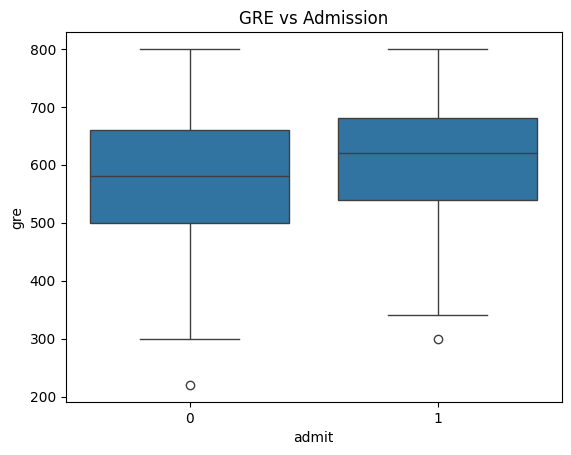

In [4]:
##Exploratory Data Analysis
df.describe()
sns.boxplot(x='admit', y='gre', data=df)

plt.title("GRE vs Admission")

plt.show()

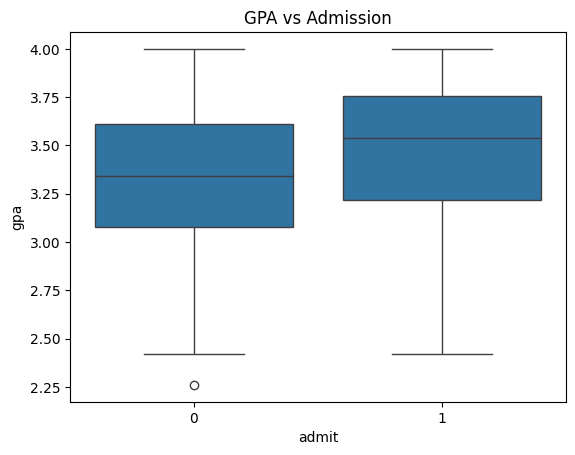

In [5]:
sns.boxplot(x='admit', y='gpa', data=df)

plt.title("GPA vs Admission")

plt.show()

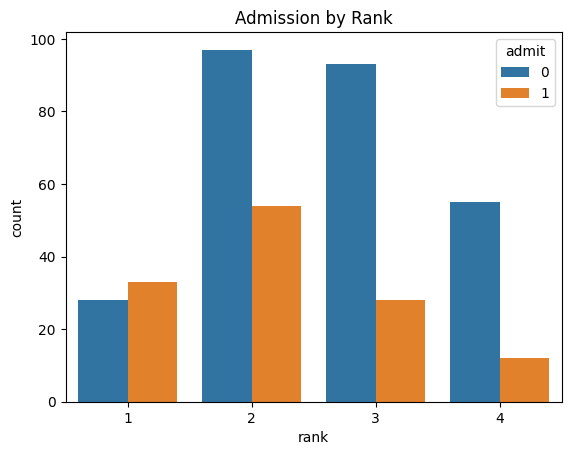

In [6]:
sns.countplot(x='rank', hue='admit', data=df)

plt.title("Admission by Rank")

plt.show()

In [7]:
#Convert Rank into Categorical Variable
df['rank'] = df['rank'].astype('category')

Fit Logistic Regression Model

Model:

admit∼gre+gpa+rank

admit∼gre+gpa+rank

In [8]:
model = smf.logit(
    'admit ~ gre + gpa + rank',
    data=df
).fit()

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6


In [9]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.08292
Time:                        11:40:42   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9900      1.140     -3.500      0.000      -6.224      -1.756
rank[T.2]     -0.6754      0.316     -2.134      0.033      -1.296      -0.055
rank[T.3]     -1.3402      0.345     -3.881      0.0

**Interpretation of Logistic Regression Results**

The logistic regression model examines how GRE score, GPA, and undergraduate institution rank affect the probability of admission into graduate school.

The overall model is statistically significant:

Likelihood Ratio p-value = 7.58 × 10⁻⁸

This indicates that the predictors collectively help explain admission outcomes.

**Interpretation of Predictors**

**GRE Score**

Coefficient = 0.0023
p-value = 0.038

Since p < 0.05, GRE is a statistically significant predictor.

A higher GRE score increases the likelihood of admission.

**GPA**

Coefficient = 0.8040
p-value = 0.015

GPA is also statistically significant.

Students with higher GPAs are more likely to be admitted into graduate school.

**Institution Rank**

Compared to rank 1 institutions (reference category):

Rank 2 coefficient = -0.6754
Rank 3 coefficient = -1.3402
Rank 4 coefficient = -1.5515

All coefficients are negative and statistically significant.

This suggests that students from lower prestige institutions have lower odds of admission compared to students from rank 1 institutions.

**Model Performance**

Pseudo R² = 0.0829

This indicates the model explains a modest proportion of variability in admission outcomes, which is common in logistic regression for real-world admission data.

**Overall Conclusion**

The analysis suggests that:

higher GRE scores,
higher GPA,
and graduating from more prestigious institutions

increase the probability of admission into graduate school.

In [10]:
#odd ratios
odds_ratios = np.exp(model.params)

print(odds_ratios)

Intercept    0.018500
rank[T.2]    0.508931
rank[T.3]    0.261792
rank[T.4]    0.211938
gre          1.002267
gpa          2.234545
dtype: float64


**Interpretation of Odds Ratios**

The odds ratios explain how each predictor affects the odds of admission to graduate school.

**GRE**

Odds Ratio = 1.002

This means that for each one-unit increase in GRE score, the odds of admission increase by about 0.2%, holding other variables constant.

**GPA**

Odds Ratio = 2.23

This indicates that a one-unit increase in GPA multiplies the odds of admission by about 2.23 times.

Higher GPA substantially increases admission chances.

**Institution Rank**

Rank 1 is the reference category.

Compared to rank 1 institutions:

Rank 2 OR = 0.51
Rank 3 OR = 0.26
Rank 4 OR = 0.21

Since these odds ratios are less than 1, students from lower-ranked institutions have lower odds of admission.

For example:

Students from rank 4 institutions have about 79% lower odds of admission compared to students from rank 1 institutions.